Load and structure SPY time series data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("spy_us_d.csv", parse_dates=["Date"])
df = df.sort_values("Date")
df.set_index("Date", inplace=True)
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2005-05-02,89.5533,89.8030,89.1415,89.8030,72660708
2005-05-03,89.5533,90.1571,89.2576,89.9666,112651084
2005-05-04,89.9916,90.8453,89.7130,90.6635,106913208
2005-05-05,90.7897,91.0378,90.0739,90.6289,126141487
2005-05-06,90.9822,91.0283,90.3200,90.3381,90213901


Computed SPY daily returns from closing prices and appended them to the dataset.

In [2]:
df["Returns"] = df["Close"].pct_change()
df = df.dropna()
df.describe()
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5282 entries, 2005-05-03 to 2026-05-01
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Open     5282 non-null   float64
 1   High     5282 non-null   float64
 2   Low      5282 non-null   float64
 3   Close    5282 non-null   float64
 4   Volume   5282 non-null   int64  
 5   Returns  5282 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 288.9 KB


Computed and added a 30-day rolling volatility measure using the standard deviation of daily SPY returns and visualized the resulting volatility time series

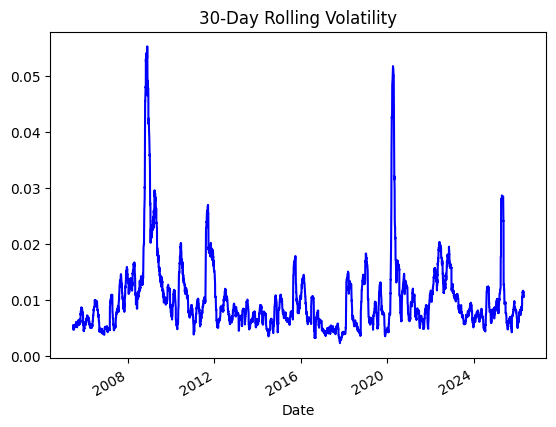

In [3]:
df["Volatility_30days"] = df["Returns"].rolling(30).std()

df["Volatility_30days"].plot(title="30-Day Rolling Volatility", color = "blue")

plt.show()

We will define extreme volatility periods using the 90th percentile of rolling volatility for tail analysis. 

In [5]:
vol_threshold = df["Volatility_30days"].quantile(0.95)

high_vol = df[df["Volatility_30days"] > vol_threshold]
low_vol = df[df["Volatility_30days"] <= vol_threshold]

Historical risk model

In [6]:
VaR_95 = np.percentile(df["Returns"], 5)
ES_95 = df[df["Returns"] <= VaR_95]["Returns"].mean()

Gaussian risk model

In [7]:
mu = df["Returns"].mean()
sigma = df["Returns"].std()

Z = np.random.normal(0, 1, 100000)

z_5 = np.percentile(Z, 5)

VaR_gaussian_95 = mu + sigma * z_5
ES_gaussian_95 = mu + sigma * Z[Z <= z_5].mean()

The difference between the Gaussian and historical tail risk estimates is partly caused by crisis periods such as the 2008 financial crisis and the 2020 COVID-19 shock, where sharp and extreme negative returns violated normality assumptions.

In [8]:
print("Historical VaR:", VaR_95)
print("Gaussian VaR:", VaR_gaussian_95)

print("Historical ES:", ES_95)
print("Gaussian ES:", ES_gaussian_95)

Historical VaR: -0.017674997375496992
Gaussian VaR: -0.019285171843121805
Historical ES: -0.02929391197436554
Gaussian ES: -0.0242898207451332


Simple static Historical VaR backtest.  

In [9]:
df["VaR_breach"] = df["Returns"] < VaR_95
breach_rate = df["VaR_breach"].mean()
print("VaR (5%):", VaR_95)
print("Observed breach rate:", breach_rate)
print("Expected breach rate: 0.05")

VaR (5%): -0.017674997375496992
Observed breach rate: 0.050170390003786446
Expected breach rate: 0.05


Rolling Historical VaR backtest. 

In [10]:
window = 252 
alpha = 0.05

# Rolling 5% historical model VaR

df["Rolling_VaR_95"] = (
    df["Returns"]
    .rolling(window)
    .quantile(alpha)
)

# VaR breach benchmark and observed rate
df["Rolling_VaR_Breach"] = (
    df["Returns"] < df["Rolling_VaR_95"]
)
rolling_breach_rate = df["Rolling_VaR_Breach"].mean()

print("Expected breach rate:", alpha)
print("Observed rolling breach rate:", rolling_breach_rate)

Expected breach rate: 0.05
Observed rolling breach rate: 0.05111700113593336


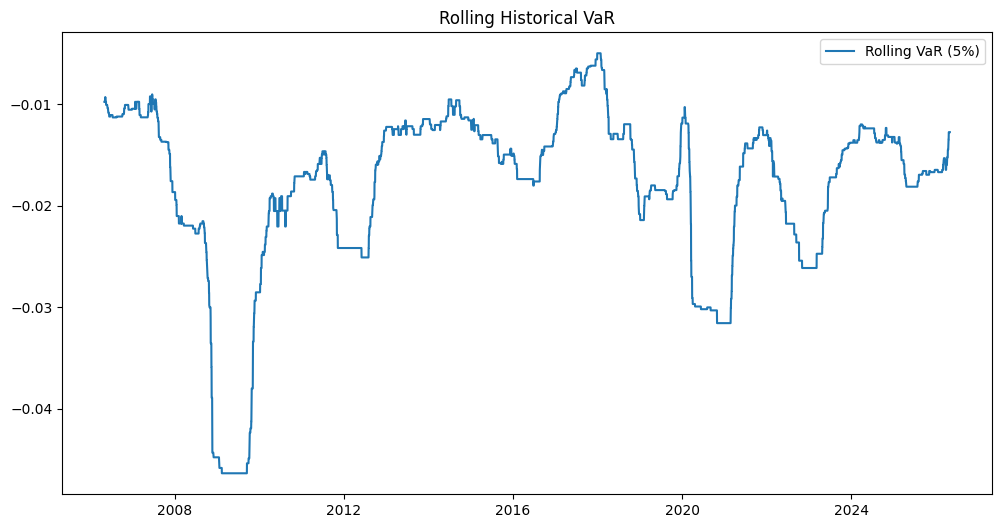

In [11]:
plt.figure(figsize=(12,6))

plt.plot(
    df.index,
    df["Rolling_VaR_95"],
    label="Rolling VaR (5%)"
)

plt.title("Rolling Historical VaR")
plt.legend()

plt.show()